In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")
print(f" pandas version: {pd.__version__}")
print(f" numpy version: {np.__version__}")

✅ All libraries imported successfully!
 pandas version: 2.2.2
 numpy version: 2.0.2


In [ ]:

np.random.seed(42)
random.seed(42)

# Define parameters
n_rides = 10000  # Number of ride records

# Cities and their coordinates (approximate)
cities = {
    'Mumbai': {'lat': 19.076, 'lon': 72.877},
    'Delhi': {'lat': 28.704, 'lon': 77.102},
    'Bangalore': {'lat': 12.971, 'lon': 77.594},
    'Hyderabad': {'lat': 17.385, 'lon': 78.486},
    'Chennai': {'lat': 13.082, 'lon': 80.270},
    'Pune': {'lat': 18.520, 'lon': 73.856},
    'Kolkata': {'lat': 22.572, 'lon': 88.363},
    'Ahmedabad': {'lat': 23.022, 'lon': 72.571}
}

# Ride types and their base fares
ride_types = {
    'Mini': {'base': 40, 'per_km': 7, 'per_min': 1},
    'Sedan': {'base': 60, 'per_km': 10, 'per_min': 1.5},
    'SUV': {'base': 100, 'per_km': 15, 'per_min': 2},
    'Premium': {'base': 150, 'per_km': 20, 'per_min': 2.5},
    'Auto': {'base': 25, 'per_km': 5, 'per_min': 0.75},
    'Bike': {'base': 15, 'per_km': 3, 'per_min': 0.5}
}

# Payment methods
payment_methods = ['Cash', 'UPI', 'Card', 'Wallet']
payment_weights = [0.25, 0.45, 0.15, 0.15]

# Generate dates (last 6 months)
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 6, 30)
date_range = (end_date - start_date).days

# Generate rides
rides_data = []

for i in range(n_rides):
    # Random booking time
    booking_date = start_date + timedelta(days=random.randint(0, date_range))
    booking_hour = random.randint(0, 23)
    booking_minute = random.randint(0, 59)
    booking_datetime = booking_date.replace(hour=booking_hour, minute=booking_minute)

    # City
    city = random.choice(list(cities.keys()))
    city_coords = cities[city]

    # Pickup location (random offset from city center)
    pickup_lat = city_coords['lat'] + np.random.uniform(-0.1, 0.1)
    pickup_lon = city_coords['lon'] + np.random.uniform(-0.1, 0.1)

    # Drop location
    drop_lat = city_coords['lat'] + np.random.uniform(-0.1, 0.1)
    drop_lon = city_coords['lon'] + np.random.uniform(-0.1, 0.1)

    # Calculate distance (simplified)
    distance_km = np.sqrt((pickup_lat - drop_lat)**2 + (pickup_lon - drop_lon)**2) * 111
    distance_km = max(1, min(distance_km, 50))  # Between 1-50 km
    distance_km = round(distance_km, 2)

    # Ride type
    ride_type = random.choice(list(ride_types.keys()))
    fare_info = ride_types[ride_type]

    # Duration (approx 2 min per km in city + random)
    duration_min = distance_km * 2 + np.random.uniform(-5, 15)
    duration_min = max(5, round(duration_min, 1))

    # Calculate fare
    base_fare = fare_info['base']
    distance_fare = distance_km * fare_info['per_km']
    time_fare = duration_min * fare_info['per_min']

    # Surge pricing (higher during peak hours)
    surge_multiplier = 1.0
    if 8 <= booking_hour <= 10 or 17 <= booking_hour <= 20:  # Peak hours
        surge_multiplier = random.choice([1.0, 1.2, 1.3, 1.5, 1.8, 2.0])
    elif 22 <= booking_hour or booking_hour <= 5:  # Late night
        surge_multiplier = random.choice([1.0, 1.1, 1.2])

    # Weekend surge
    if booking_date.weekday() >= 5:
        surge_multiplier *= random.choice([1.0, 1.1, 1.2])

    total_fare = round((base_fare + distance_fare + time_fare) * surge_multiplier, 2)

    # Ride status
    status_weights = [0.78, 0.12, 0.10]  # Completed, Cancelled, No Driver
    status = random.choices(['Completed', 'Cancelled', 'No Driver Available'],
                           weights=status_weights)[0]

    # If cancelled or no driver, fare is 0 or cancellation fee
    if status == 'Cancelled':
        total_fare = round(random.choice([0, 25, 50]), 2)
    elif status == 'No Driver Available':
        total_fare = 0

    # Payment method (only for completed rides)
    if status == 'Completed':
        payment = random.choices(payment_methods, weights=payment_weights)[0]
    else:
        payment = None

    # Rating (only for completed rides)
    if status == 'Completed':
        # Most people give 4-5 stars
        rating = random.choices([1, 2, 3, 4, 5],
                               weights=[0.02, 0.05, 0.13, 0.35, 0.45])[0]
    else:
        rating = None

    # Driver ID
    driver_id = f"DR{random.randint(1000, 9999)}"

    # Customer ID
    customer_id = f"CUST{random.randint(10000, 99999)}"

    # Ride ID
    ride_id = f"RIDE{i+100001}"

    # Append to list
    rides_data.append({
        'Ride_ID': ride_id,
        'Booking_DateTime': booking_datetime,
        'Date': booking_date.date(),
        'Time': booking_datetime.time(),
        'Hour': booking_hour,
        'Day_of_Week': booking_date.strftime('%A'),
        'Month': booking_date.strftime('%B'),
        'City': city,
        'Pickup_Lat': round(pickup_lat, 6),
        'Pickup_Lon': round(pickup_lon, 6),
        'Drop_Lat': round(drop_lat, 6),
        'Drop_Lon': round(drop_lon, 6),
        'Distance_KM': distance_km,
        'Duration_Min': duration_min,
        'Ride_Type': ride_type,
        'Base_Fare': base_fare,
        'Surge_Multiplier': surge_multiplier,
        'Total_Fare': total_fare,
        'Status': status,
        'Payment_Method': payment,
        'Rating': rating,
        'Driver_ID': driver_id,
        'Customer_ID': customer_id
    })

# Create DataFrame
df = pd.DataFrame(rides_data)

print("✅ Dataset created successfully!")
print(f"📊 Total rides: {len(df):,}")
print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"🏙️ Cities covered: {df['City'].nunique()}")
print(f"🚗 Ride types: {df['Ride_Type'].nunique()}")


✅ Dataset created successfully!
📊 Total rides: 10,000
📅 Date range: 2024-01-01 to 2024-06-30
🏙️ Cities covered: 8
🚗 Ride types: 6


In [ ]:
# View first 10 rows
print("=" * 80)
print("📋 FIRST 10 ROWS OF DATASET")
print("=" * 80)
df.head(10)

📋 FIRST 10 ROWS OF DATASET


,Ride_ID,Booking_DateTime,Date,Time,Hour,Day_of_Week,Month,City,Pickup_Lat,Pickup_Lon,Drop_Lat,Drop_Lon,Distance_KM,Duration_Min,Ride_Type,Base_Fare,Surge_Multiplier,Total_Fare,Status,Payment_Method,Rating,Driver_ID,Customer_ID
0,RIDE100001,2024-06-12 03:01:00,2024-06-12,03:01:00,3,Wednesday,June,Chennai,13.056908,80.360143,13.128399,80.289732,11.14,20.4,Sedan,60,1.00,202.00,Completed,Cash,5.0,DR9935,CUST21395
1,RIDE100002,2024-05-31 13:02:00,2024-05-31,13:02:00,13,Friday,May,Mumbai,19.007199,72.788617,19.149235,72.897223,19.85,48.9,Mini,40,1.00,227.85,Completed,UPI,2.0,DR4257,CUST95181
2,RIDE100003,2024-06-28 17:26:00,2024-06-28,17:26:00,17,Friday,June,Hyderabad,17.289117,78.579982,17.451489,78.428468,24.65,47.9,Premium,150,1.80,1372.95,Completed,Wallet,5.0,DR3615,CUST65392
3,RIDE100004,2024-03-28 08:09:00,2024-03-28,08:09:00,8,Thursday,March,Hyderabad,17.321681,78.446848,17.389951,78.472389,8.09,17.0,SUV,100,1.00,255.35,Completed,Cash,5.0,DR5333,CUST15695
4,RIDE100005,2024-04-27 17:07:00,2024-04-27,17:07:00,17,Saturday,April,Kolkata,22.594371,88.290899,22.530429,88.336272,8.70,21.5,Mini,40,1.98,50.00,Cancelled,None,NaN,DR6925,CUST85674
5,RIDE100006,2024-02-19 22:04:00,2024-02-19,22:04:00,22,Monday,February,Mumbai,19.133035,72.816935,19.078847,72.895483,10.59,17.1,Bike,15,1.00,55.32,Completed,Wallet,5.0,DR2654,CUST59823
6,RIDE100007,2024-03-12 14:40:00,2024-03-12,14:40:00,14,Tuesday,March,Pune,18.541509,73.790105,18.433010,73.945777,21.06,56.4,Sedan,60,1.00,355.20,Completed,Cash,4.0,DR2169,CUST89840
7,RIDE100008,2024-06-11 05:34:00,2024-06-11,05:34:00,5,Tuesday,June,Hyderabad,17.446679,78.446923,17.304534,78.522847,17.89,39.6,Sedan,60,1.10,328.13,Completed,Wallet,5.0,DR4598,CUST99733
8,RIDE100009,2024-03-24 01:14:00,2024-03-24,01:14:00,1,Sunday,March,Mumbai,19.000408,72.876035,18.982878,72.958864,9.40,19.0,SUV,100,1.21,337.59,Completed,Wallet,5.0,DR6155,CUST37869
9,RIDE100010,2024-06-16 15:25:00,2024-06-16,15:25:00,15,Sunday,June,Ahmedabad,23.054504,72.533342,23.026014,72.580342,6.10,10.9,Sedan,60,1.10,151.08,Completed,Card,4.0,DR8019,CUST86484


In [ ]:
# Basic information about the dataset
print("=" * 80)
print("📊 DATASET INFORMATION")
print("=" * 80)

print(f"\n🔹 Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n🔹 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n🔹 Data Types:")
print(df.dtypes)

print(f"\n🔹 Basic Statistics (Numeric Columns):")
df.describe().round(2)

📊 DATASET INFORMATION

🔹 Shape: 10000 rows x 23 columns

🔹 Column Names:
    1. Ride_ID
    2. Booking_DateTime
    3. Date
    4. Time
    5. Hour
    6. Day_of_Week
    7. Month
    8. City
    9. Pickup_Lat
   10. Pickup_Lon
   11. Drop_Lat
   12. Drop_Lon
   13. Distance_KM
   14. Duration_Min
   15. Ride_Type
   16. Base_Fare
   17. Surge_Multiplier
   18. Total_Fare
   19. Status
   20. Payment_Method
   21. Rating
   22. Driver_ID
   23. Customer_ID

🔹 Data Types:
Ride_ID                     object
Booking_DateTime    datetime64[ns]
Date                        object
Time                        object
Hour                         int64
Day_of_Week                 object
Month                       object
City                        object
Pickup_Lat                 float64
Pickup_Lon                 float64
Drop_Lat                   float64
Drop_Lon                   float64
Distance_KM                float64
Duration_Min               float64
Ride_Type                   object

,Booking_DateTime,Hour,Pickup_Lat,Pickup_Lon,Drop_Lat,Drop_Lon,Distance_KM,Duration_Min,Base_Fare,Surge_Multiplier,Total_Fare,Rating
count,10000,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,7741.00
mean,2024-04-01 06:26:51.996000,11.56,19.46,77.60,19.46,77.60,11.67,28.35,64.97,1.21,210.44,4.14
min,2024-01-01 00:54:00,0.00,12.87,72.47,12.87,72.47,1.00,5.00,15.00,1.00,0.00,1.00
25%,2024-02-15 23:47:45,6.00,17.29,72.97,17.29,72.97,7.43,19.50,25.00,1.00,50.00,4.00
50%,2024-04-01 12:30:00,12.00,18.99,77.19,18.98,77.19,11.51,28.00,40.00,1.10,144.04,4.00
75%,2024-05-16 12:40:45,18.00,22.93,78.58,22.93,78.58,15.70,37.10,100.00,1.20,311.36,5.00
max,2024-06-30 23:49:00,23.00,28.80,88.46,28.80,88.46,28.35,68.50,150.00,2.40,1505.63,5.00
std,NaN,6.92,4.96,4.82,4.96,4.82,5.46,12.18,47.11,0.29,212.36,0.97


In [ ]:
# Check missing values
print("=" * 80)
print("🔍 MISSING VALUE ANALYSIS")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])
print(f"\n✅ Total missing values: {df.isnull().sum().sum():,}")


🔍 MISSING VALUE ANALYSIS
                Missing Count  Missing %
Payment_Method           2259      22.59
Rating                   2259      22.59

✅ Total missing values: 4,518


In [ ]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Create Time Period categories
def get_time_period(hour):
    if 5 <= hour < 8:
        return 'Early Morning'
    elif 8 <= hour < 12:
        return 'Morning Peak'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 20:
        return 'Evening Peak'
    elif 20 <= hour < 23:
        return 'Night'
    else:
        return 'Late Night'

df_clean['Time_Period'] = df_clean['Hour'].apply(get_time_period)

# 2. Create Weekend flag
df_clean['Is_Weekend'] = df_clean['Day_of_Week'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})

# 3. Create Fare per KM
df_clean['Fare_Per_KM'] = round(df_clean['Total_Fare'] / df_clean['Distance_KM'], 2)
df_clean['Fare_Per_KM'] = df_clean['Fare_Per_KM'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Create Speed (KM/Hour)
df_clean['Speed_KMH'] = round(df_clean['Distance_KM'] / (df_clean['Duration_Min'] / 60), 2)
df_clean['Speed_KMH'] = df_clean['Speed_KMH'].replace([np.inf, -np.inf], 0).fillna(0)

# 5. Create Distance Categories
def get_distance_cat(dist):
    if dist <= 5:
        return 'Short (0-5 km)'
    elif dist <= 15:
        return 'Medium (5-15 km)'
    elif dist <= 30:
        return 'Long (15-30 km)'
    else:
        return 'Very Long (30+ km)'

df_clean['Distance_Category'] = df_clean['Distance_KM'].apply(get_distance_cat)

# 6. Create Fare Categories
def get_fare_cat(fare):
    if fare <= 50:
        return 'Low (≤₹50)'
    elif fare <= 150:
        return 'Medium (₹50-150)'
    elif fare <= 300:
        return 'High (₹150-300)'
    else:
        return 'Premium (₹300+)'

df_clean['Fare_Category'] = df_clean['Total_Fare'].apply(get_fare_cat)

# 7. Round off some columns
df_clean['Distance_KM'] = df_clean['Distance_KM'].round(2)
df_clean['Duration_Min'] = df_clean['Duration_Min'].round(1)

print("✅ Data cleaning completed!")
print(f"\n🆕 New columns added:")
new_cols = ['Time_Period', 'Is_Weekend', 'Fare_Per_KM', 'Speed_KMH', 'Distance_Category', 'Fare_Category']
for col in new_cols:
    print(f"   ✓ {col}")

print(f"\n📊 Updated shape: {df_clean.shape}")


✅ Data cleaning completed!

🆕 New columns added:
   ✓ Time_Period
   ✓ Is_Weekend
   ✓ Fare_Per_KM
   ✓ Speed_KMH
   ✓ Distance_Category
   ✓ Fare_Category

📊 Updated shape: (10000, 29)


In [ ]:
# Key Metrics Dashboard
print("=" * 80)
print("📊 KEY BUSINESS METRICS")
print("=" * 80)

total_rides = len(df_clean)
completed_rides = len(df_clean[df_clean['Status'] == 'Completed'])
cancelled_rides = len(df_clean[df_clean['Status'] == 'Cancelled'])
no_driver = len(df_clean[df_clean['Status'] == 'No Driver Available'])
completion_rate = (completed_rides / total_rides * 100)
cancellation_rate = (cancelled_rides / total_rides * 100)

total_revenue = df_clean[df_clean['Status'] == 'Completed']['Total_Fare'].sum()
avg_fare = df_clean[df_clean['Status'] == 'Completed']['Total_Fare'].mean()
avg_distance = df_clean[df_clean['Status'] == 'Completed']['Distance_KM'].mean()
avg_rating = df_clean[df_clean['Status'] == 'Completed']['Rating'].mean()

print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    🚗 RIDE SUMMARY                          │
├─────────────────────────────────────────────────────────────┤
│  Total Rides Booked     :  {total_rides:>10,}                    │
│  Completed Rides        :  {completed_rides:>10,}                    │
│  Cancelled Rides        :  {cancelled_rides:>10,}                    │
│  No Driver Found        :  {no_driver:>10,}                    │
├─────────────────────────────────────────────────────────────┤
│  Completion Rate        :  {completion_rate:>10.2f}%                    │
│  Cancellation Rate      :  {cancellation_rate:>10.2f}%                    │
├─────────────────────────────────────────────────────────────┤
│  💰 Total Revenue       :  ₹{total_revenue:>12,.2f}                  │
│  💰 Average Fare        :  ₹{avg_fare:>12,.2f}                  │
│  📏 Average Distance    :  {avg_distance:>12.2f} km                │
│  ⭐ Average Rating      :  {avg_rating:>12.2f} /5                │
└─────────────────────────────────────────────────────────────┘
""")

📊 KEY BUSINESS METRICS

┌─────────────────────────────────────────────────────────────┐
│                    🚗 RIDE SUMMARY                          │
├─────────────────────────────────────────────────────────────┤
│  Total Rides Booked     :      10,000                    │
│  Completed Rides        :       7,741                    │
│  Cancelled Rides        :       1,239                    │
│  No Driver Found        :       1,020                    │
├─────────────────────────────────────────────────────────────┤
│  Completion Rate        :       77.41%                    │
│  Cancellation Rate      :       12.39%                    │
├─────────────────────────────────────────────────────────────┤
│  💰 Total Revenue       :  ₹2,073,389.90                  │
│  💰 Average Fare        :  ₹      267.85                  │
│  📏 Average Distance    :         11.71 km                │
│  ⭐ Average Rating      :          4.14 /5                │
└────────────────────────────────────────────

In [ ]:
# City-wise Analysis
print("=" * 80)
print("🏙️ CITY-WISE ANALYSIS")
print("=" * 80)

city_analysis = df_clean[df_clean['Status'] == 'Completed'].groupby('City').agg({
    'Ride_ID': 'count',
    'Total_Fare': ['sum', 'mean'],
    'Distance_KM': 'mean',
    'Rating': 'mean'
}).round(2)

city_analysis.columns = ['Total_Rides', 'Total_Revenue', 'Avg_Fare', 'Avg_Distance', 'Avg_Rating']
city_analysis = city_analysis.sort_values('Total_Revenue', ascending=False)
city_analysis['Revenue_Share_%'] = (city_analysis['Total_Revenue'] / city_analysis['Total_Revenue'].sum() * 100).round(2)

print(city_analysis.to_string())

🏙️ CITY-WISE ANALYSIS
           Total_Rides  Total_Revenue  Avg_Fare  Avg_Distance  Avg_Rating  Revenue_Share_%
City                                                                                      
Mumbai            1018      274154.54    269.31         11.57        4.17            13.22
Ahmedabad          982      270250.48    275.20         11.67        4.19            13.03
Kolkata            954      261765.84    274.39         11.99        4.12            12.63
Pune               977      259839.70    265.96         11.62        4.14            12.53
Delhi              970      259303.54    267.32         11.85        4.13            12.51
Bangalore          971      258922.64    266.66         11.81        4.14            12.49
Hyderabad          941      250046.74    265.72         11.76        4.11            12.06
Chennai            928      239106.42    257.66         11.41        4.15            11.53


In [ ]:
# Hourly booking pattern
print("=" * 80)
print("⏰ HOURLY BOOKING PATTERN")
print("=" * 80)

hourly = df_clean.groupby('Hour').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum'
}).round(2)
hourly.columns = ['Total_Bookings', 'Total_Revenue']
hourly['Avg_Bookings_Per_Hour'] = hourly['Total_Bookings'].mean().round(0)

# Identify peak hours
peak_hour = hourly['Total_Bookings'].idxmax()
low_hour = hourly['Total_Bookings'].idxmin()

print(hourly.to_string())
print(f"\n🔥 Peak Hour: {peak_hour}:00 ({hourly.loc[peak_hour, 'Total_Bookings']} bookings)")
print(f"📉 Lowest Hour: {low_hour}:00 ({hourly.loc[low_hour, 'Total_Bookings']} bookings)")

⏰ HOURLY BOOKING PATTERN
      Total_Bookings  Total_Revenue  Avg_Bookings_Per_Hour
Hour                                                      
0                405       82436.54                  417.0
1                418       78006.10                  417.0
2                422       80282.22                  417.0
3                435       86668.35                  417.0
4                384       73727.12                  417.0
5                435       89790.80                  417.0
6                411       77664.19                  417.0
7                381       66014.22                  417.0
8                417      108830.24                  417.0
9                422      107334.56                  417.0
10               390      109904.02                  417.0
11               400       75732.35                  417.0
12               438       79824.89                  417.0
13               406       79173.33                  417.0
14               433       7614

In [ ]:
# Day of week analysis
print("=" * 80)
print("📅 DAY OF WEEK ANALYSIS")
print("=" * 80)

# Order days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_analysis = df_clean[df_clean['Status'] == 'Completed'].groupby('Day_of_Week').agg({
    'Ride_ID': 'count',
    'Total_Fare': ['sum', 'mean'],
    'Rating': 'mean'
}).round(2)
day_analysis.columns = ['Total_Rides', 'Total_Revenue', 'Avg_Fare', 'Avg_Rating']
day_analysis = day_analysis.reindex(day_order)

print(day_analysis.to_string())

📅 DAY OF WEEK ANALYSIS
             Total_Rides  Total_Revenue  Avg_Fare  Avg_Rating
Day_of_Week                                                  
Monday              1083      288585.56    266.47        4.14
Tuesday             1159      296016.47    255.41        4.14
Wednesday           1088      287085.75    263.87        4.17
Thursday            1133      297996.43    263.02        4.13
Friday              1069      280359.23    262.26        4.16
Saturday            1051      301797.87    287.15        4.10
Sunday              1158      321548.59    277.68        4.16


In [ ]:
# Ride type analysis
print("=" * 80)
print("🚗 RIDE TYPE ANALYSIS")
print("=" * 80)

ride_type_analysis = df_clean[df_clean['Status'] == 'Completed'].groupby('Ride_Type').agg({
    'Ride_ID': 'count',
    'Total_Fare': ['sum', 'mean'],
    'Distance_KM': 'mean',
    'Fare_Per_KM': 'mean',
    'Rating': 'mean'
}).round(2)

ride_type_analysis.columns = ['Total_Rides', 'Total_Revenue', 'Avg_Fare', 'Avg_Distance', 'Avg_Fare_per_KM', 'Avg_Rating']
ride_type_analysis = ride_type_analysis.sort_values('Total_Revenue', ascending=False)
ride_type_analysis['Ride_Share_%'] = (ride_type_analysis['Total_Rides'] / ride_type_analysis['Total_Rides'].sum() * 100).round(2)

print(ride_type_analysis.to_string())

🚗 RIDE TYPE ANALYSIS
           Total_Rides  Total_Revenue  Avg_Fare  Avg_Distance  Avg_Fare_per_KM  Avg_Rating  Ride_Share_%
Ride_Type                                                                                               
Premium           1303      720706.13    553.11         11.85            54.21        4.17         16.83
SUV               1308      526597.19    402.60         11.76            39.55        4.15         16.90
Sedan             1229      321596.42    261.67         11.61            26.16        4.17         15.88
Mini              1361      247691.96    181.99         11.77            17.43        4.14         17.58
Auto              1236      156165.27    126.35         11.71            12.13        4.15         15.97
Bike              1304      100632.93     77.17         11.55             7.57        4.09         16.85


In [ ]:
# Payment method analysis
print("=" * 80)
print("💳 PAYMENT METHOD ANALYSIS")
print("=" * 80)

payment_analysis = df_clean[df_clean['Status'] == 'Completed'].groupby('Payment_Method').agg({
    'Ride_ID': 'count',
    'Total_Fare': ['sum', 'mean']
}).round(2)

payment_analysis.columns = ['Transaction_Count', 'Total_Revenue', 'Avg_Transaction']
payment_analysis = payment_analysis.sort_values('Total_Revenue', ascending=False)
payment_analysis['Payment_Share_%'] = (payment_analysis['Transaction_Count'] / payment_analysis['Transaction_Count'].sum() * 100).round(2)

print(payment_analysis.to_string())

💳 PAYMENT METHOD ANALYSIS
                Transaction_Count  Total_Revenue  Avg_Transaction  Payment_Share_%
Payment_Method                                                                    
UPI                          3439      925038.19           268.98            44.43
Cash                         1947      522718.76           268.47            25.15
Wallet                       1208      321183.09           265.88            15.61
Card                         1147      304449.86           265.43            14.82


In [ ]:
# Cancellation analysis
print("=" * 80)
print("❌ CANCELLATION ANALYSIS")
print("=" * 80)

# Overall cancellation
cancelled = df_clean[df_clean['Status'] == 'Cancelled']

print(f"\n📊 Overall Cancellation Rate: {len(cancelled)/len(df_clean)*100:.2f}%")

# By city
print("\n🏙️ Cancellation by City:")
city_cancel = cancelled.groupby('City').size().sort_values(ascending=False)
city_total = df_clean.groupby('City').size()
city_cancel_rate = (city_cancel / city_total * 100).round(2)
print(city_cancel_rate.sort_values(ascending=False).to_string())

# By hour
print("\n⏰ Cancellation by Hour:")
hour_cancel = cancelled.groupby('Hour').size()
hour_total = df_clean.groupby('Hour').size()
hour_cancel_rate = (hour_cancel / hour_total * 100).round(2)
print(hour_cancel_rate.sort_values(ascending=False).head(5).to_string())

# By ride type
print("\n🚗 Cancellation by Ride Type:")
type_cancel = cancelled.groupby('Ride_Type').size()
type_total = df_clean.groupby('Ride_Type').size()
type_cancel_rate = (type_cancel / type_total * 100).round(2)
print(type_cancel_rate.sort_values(ascending=False).to_string())

# Lost revenue due to cancellation
lost_revenue = cancelled['Total_Fare'].sum()
print(f"\n💸 Lost Revenue (Cancellation Fees Only): ₹{lost_revenue:,.2f}")

❌ CANCELLATION ANALYSIS

📊 Overall Cancellation Rate: 12.39%

🏙️ Cancellation by City:
City
Chennai      13.18
Delhi        13.03
Bangalore    12.95
Kolkata      12.58
Pune         12.41
Hyderabad    12.12
Mumbai       11.62
Ahmedabad    11.24

⏰ Cancellation by Hour:
Hour
18    14.95
3     14.71
15    14.25
20    13.74
9     13.27

🚗 Cancellation by Ride Type:
Ride_Type
Bike       13.76
Auto       12.83
Sedan      12.48
Premium    12.19
SUV        11.77
Mini       11.33

💸 Lost Revenue (Cancellation Fees Only): ₹31,025.00


In [ ]:
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define colors
colors = ['#0ea5e9', '#f59e0b', '#10b981', '#ef4444', '#8b5cf6', '#ec4899']

print("✅ Plotting style set!")

✅ Plotting style set!


/tmp/ipykernel_3807/3931827529.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3931827529.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3931827529.py:32: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
 

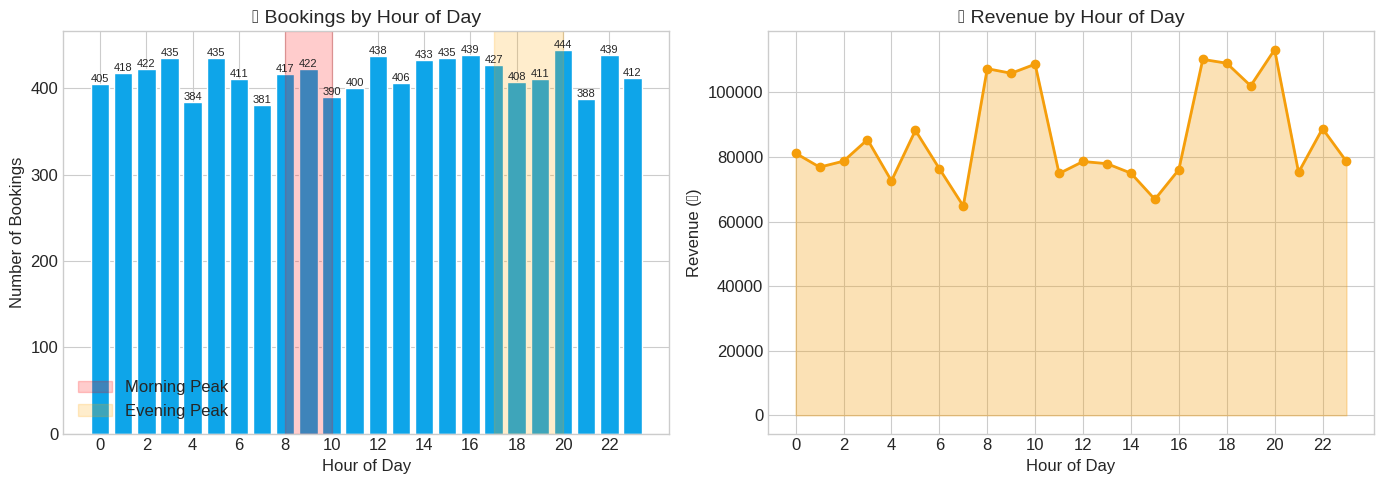

In [ ]:
# Hourly booking pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bookings by hour
hourly_bookings = df_clean.groupby('Hour')['Ride_ID'].count()
ax1 = axes[0]
bars = ax1.bar(hourly_bookings.index, hourly_bookings.values, color='#0ea5e9', edgecolor='white')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Bookings')
ax1.set_title('📈 Bookings by Hour of Day')
ax1.set_xticks(range(0, 24, 2))
ax1.axvspan(8, 10, alpha=0.2, color='red', label='Morning Peak')
ax1.axvspan(17, 20, alpha=0.2, color='orange', label='Evening Peak')
ax1.legend()

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Revenue by hour
hourly_revenue = df_clean[df_clean['Status'] == 'Completed'].groupby('Hour')['Total_Fare'].sum()
ax2 = axes[1]
ax2.plot(hourly_revenue.index, hourly_revenue.values, color='#f59e0b', linewidth=2, marker='o')
ax2.fill_between(hourly_revenue.index, hourly_revenue.values, alpha=0.3, color='#f59e0b')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Revenue (₹)')
ax2.set_title('💰 Revenue by Hour of Day')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

/tmp/ipykernel_3807/72088794.py:39: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/72088794.py:39: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/72088794.py:39: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/72088794.py:39: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/c

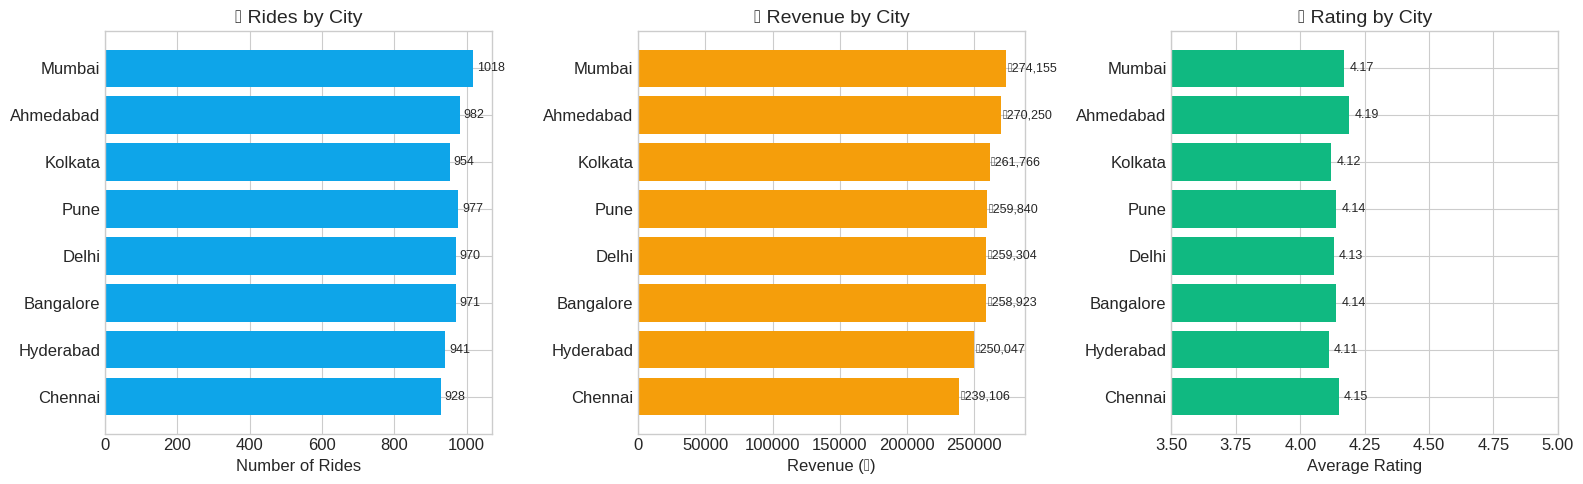

In [ ]:
# City-wise analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

city_data = df_clean[df_clean['Status'] == 'Completed'].groupby('City').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum',
    'Rating': 'mean'
}).round(2)
city_data.columns = ['Rides', 'Revenue', 'Rating']

# Sort by revenue
city_data = city_data.sort_values('Revenue', ascending=True)

# Rides by city
ax1 = axes[0]
ax1.barh(city_data.index, city_data['Rides'], color=colors[0])
ax1.set_xlabel('Number of Rides')
ax1.set_title('🚗 Rides by City')
for i, v in enumerate(city_data['Rides']):
    ax1.text(v + 10, i, f'{int(v)}', va='center', fontsize=9)

# Revenue by city
ax2 = axes[1]
ax2.barh(city_data.index, city_data['Revenue'], color=colors[1])
ax2.set_xlabel('Revenue (₹)')
ax2.set_title('💰 Revenue by City')
for i, v in enumerate(city_data['Revenue']):
    ax2.text(v + 1000, i, f'₹{v:,.0f}', va='center', fontsize=9)

# Rating by city
ax3 = axes[2]
ax3.barh(city_data.index, city_data['Rating'], color=colors[2])
ax3.set_xlabel('Average Rating')
ax3.set_title('⭐ Rating by City')
ax3.set_xlim(3.5, 5)
for i, v in enumerate(city_data['Rating']):
    ax3.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3807/2084443740.py:29: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/2084443740.py:29: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/2084443740.py:29: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(byt

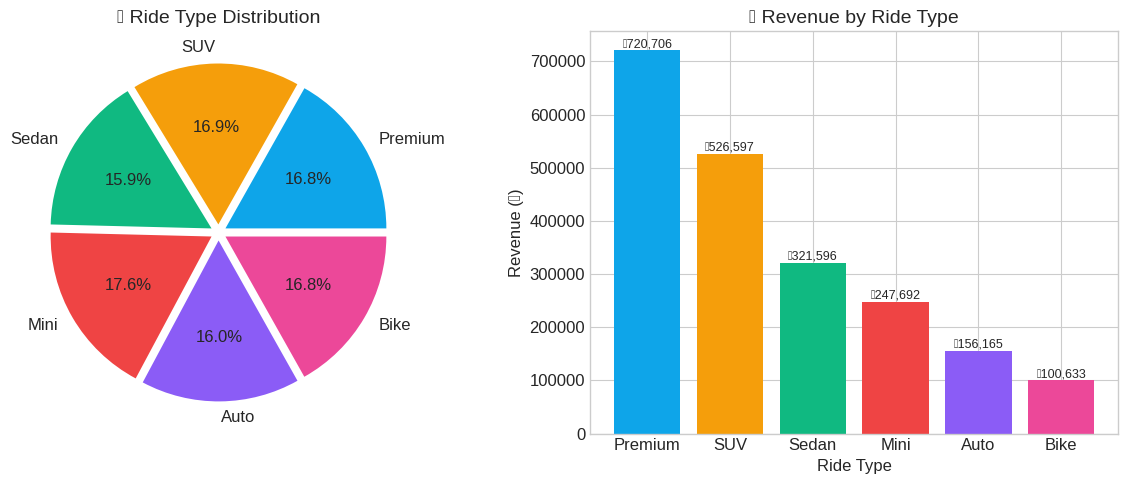

In [ ]:
# Ride type analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ride_data = df_clean[df_clean['Status'] == 'Completed'].groupby('Ride_Type').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum'
}).round(2)
ride_data.columns = ['Rides', 'Revenue']
ride_data = ride_data.sort_values('Revenue', ascending=False)

# Pie chart for ride distribution
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(ride_data['Rides'], labels=ride_data.index,
                                    autopct='%1.1f%%', colors=colors[:len(ride_data)],
                                    explode=[0.05]*len(ride_data))
ax1.set_title('🚗 Ride Type Distribution')

# Revenue by ride type
ax2 = axes[1]
bars = ax2.bar(ride_data.index, ride_data['Revenue'], color=colors[:len(ride_data)])
ax2.set_xlabel('Ride Type')
ax2.set_ylabel('Revenue (₹)')
ax2.set_title('💰 Revenue by Ride Type')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3807/3524803181.py:32: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3524803181.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3524803181.py:32: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(b

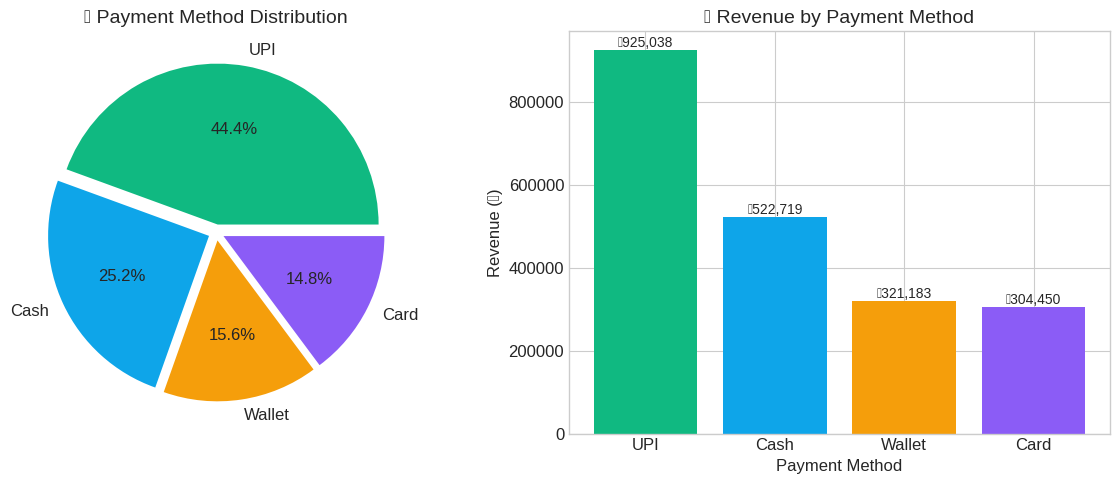

In [ ]:
# Payment method distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

payment_data = df_clean[df_clean['Status'] == 'Completed'].groupby('Payment_Method').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum'
}).round(2)
payment_data.columns = ['Transactions', 'Revenue']
payment_data = payment_data.sort_values('Revenue', ascending=False)

# Pie chart
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(payment_data['Transactions'],
                                    labels=payment_data.index,
                                    autopct='%1.1f%%',
                                    colors=['#10b981', '#0ea5e9', '#f59e0b', '#8b5cf6'],
                                    explode=[0.05]*len(payment_data))
ax1.set_title('💳 Payment Method Distribution')

# Revenue bar chart
ax2 = axes[1]
bars = ax2.bar(payment_data.index, payment_data['Revenue'],
               color=['#10b981', '#0ea5e9', '#f59e0b', '#8b5cf6'])
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Revenue (₹)')
ax2.set_title('💰 Revenue by Payment Method')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_3807/3615359775.py:33: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3615359775.py:33: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/3615359775.py:33: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_i

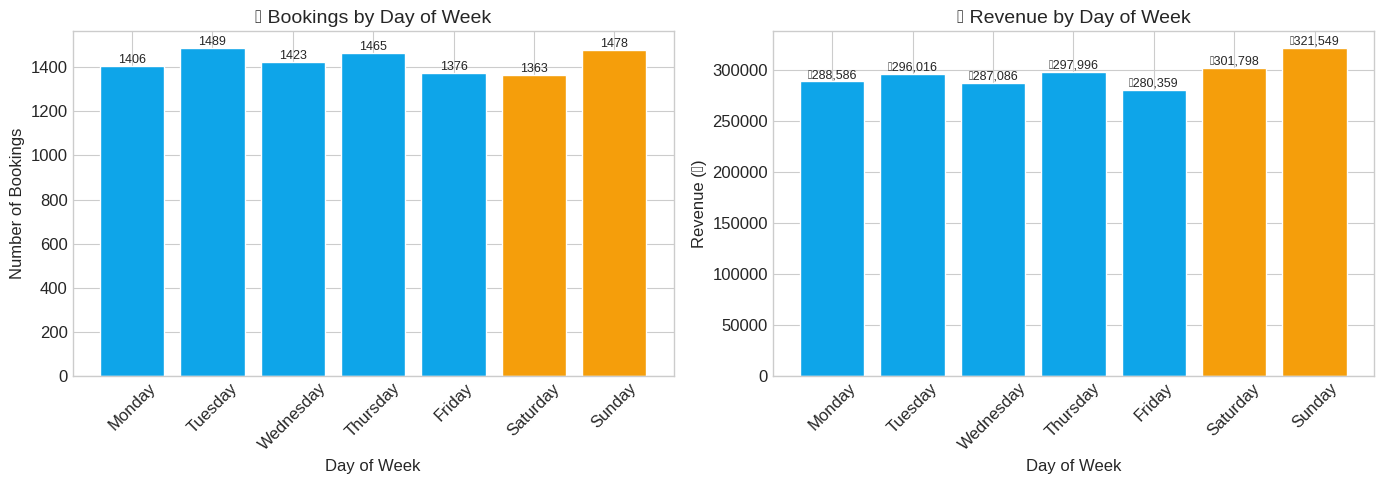

In [ ]:
# Day of week pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_rides = df_clean.groupby('Day_of_Week')['Ride_ID'].count().reindex(day_order)
day_revenue = df_clean[df_clean['Status'] == 'Completed'].groupby('Day_of_Week')['Total_Fare'].sum().reindex(day_order)

# Rides by day
ax1 = axes[0]
bars = ax1.bar(day_order, day_rides.values, color=['#0ea5e9']*5 + ['#f59e0b']*2, edgecolor='white')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Number of Bookings')
ax1.set_title('📅 Bookings by Day of Week')
ax1.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Revenue by day
ax2 = axes[1]
bars = ax2.bar(day_order, day_revenue.values, color=['#0ea5e9']*5 + ['#f59e0b']*2, edgecolor='white')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Revenue (₹)')
ax2.set_title('💰 Revenue by Day of Week')
ax2.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3807/2775291982.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/2775291982.py:28: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


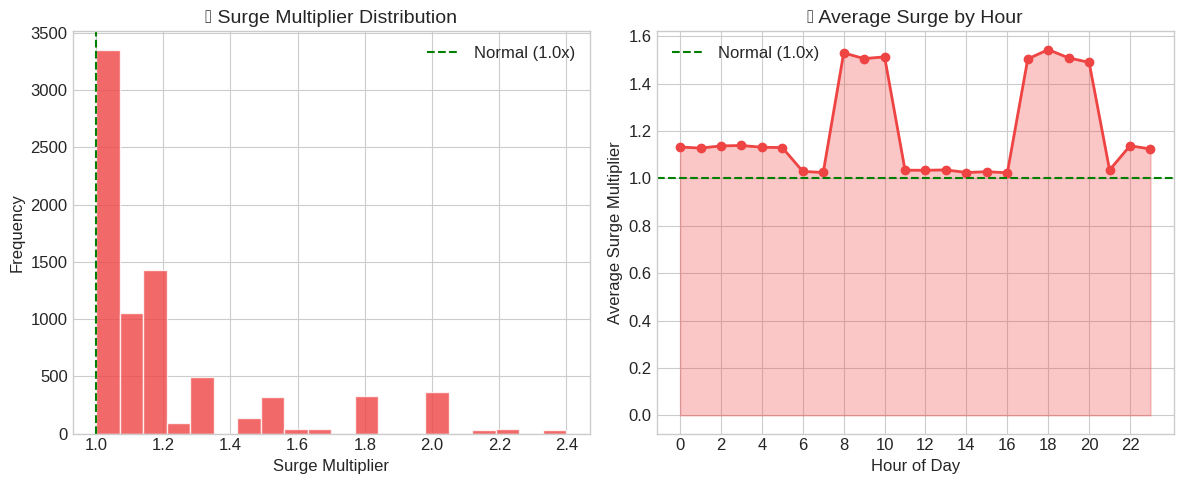


📊 Surge Statistics:
   Average Surge: 1.20x
   Maximum Surge: 2.40x
   Rides with Surge (>1.0x): 4,394 (56.8%)
   Extra Revenue from Surge: ₹352,849.28


In [ ]:
# Surge pricing analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Filter only completed rides
surge_data = df_clean[df_clean['Status'] == 'Completed'].copy()

# Surge distribution
ax1 = axes[0]
ax1.hist(surge_data['Surge_Multiplier'], bins=20, color='#ef4444', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Surge Multiplier')
ax1.set_ylabel('Frequency')
ax1.set_title('📈 Surge Multiplier Distribution')
ax1.axvline(x=1.0, color='green', linestyle='--', label='Normal (1.0x)')
ax1.legend()

# Surge by hour
surge_by_hour = surge_data.groupby('Hour')['Surge_Multiplier'].mean()
ax2 = axes[1]
ax2.plot(surge_by_hour.index, surge_by_hour.values, color='#ef4444', linewidth=2, marker='o')
ax2.fill_between(surge_by_hour.index, surge_by_hour.values, alpha=0.3, color='#ef4444')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Average Surge Multiplier')
ax2.set_title('🔥 Average Surge by Hour')
ax2.axhline(y=1.0, color='green', linestyle='--', label='Normal (1.0x)')
ax2.set_xticks(range(0, 24, 2))
ax2.legend()

plt.tight_layout()
plt.show()

# --- FIXED MATH FOR EXTRA REVENUE ---
# Step 1: Create dictionaries for the rates
per_km_rates = {'Mini': 7, 'Sedan': 10, 'SUV': 15, 'Premium': 20, 'Auto': 5, 'Bike': 3}
per_min_rates = {'Mini': 1, 'Sedan': 1.5, 'SUV': 2, 'Premium': 2.5, 'Auto': 0.75, 'Bike': 0.5}

# Step 2: Calculate what the fare WOULD BE without surge (Base Fare + Distance + Time)
normal_fare = (surge_data['Base_Fare'] +
               (surge_data['Distance_KM'] * surge_data['Ride_Type'].map(per_km_rates)) +
               (surge_data['Duration_Min'] * surge_data['Ride_Type'].map(per_min_rates)))

# Step 3: Calculate the extra money made from surge
extra_revenue = (surge_data['Total_Fare'] - normal_fare).sum()

# Step 4: Calculate other stats
avg_surge = surge_data['Surge_Multiplier'].mean()
max_surge = surge_data['Surge_Multiplier'].max()
rides_with_surge = (surge_data['Surge_Multiplier'] > 1.0).sum()
surge_percentage = (rides_with_surge / len(surge_data)) * 100

# Step 5: Print everything cleanly (no complex math inside the print statement!)
print(f"\n📊 Surge Statistics:")
print(f"   Average Surge: {avg_surge:.2f}x")
print(f"   Maximum Surge: {max_surge:.2f}x")
print(f"   Rides with Surge (>1.0x): {rides_with_surge:,} ({surge_percentage:.1f}%)")
print(f"   Extra Revenue from Surge: ₹{extra_revenue:,.2f}")


/tmp/ipykernel_3807/2290418574.py:30: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


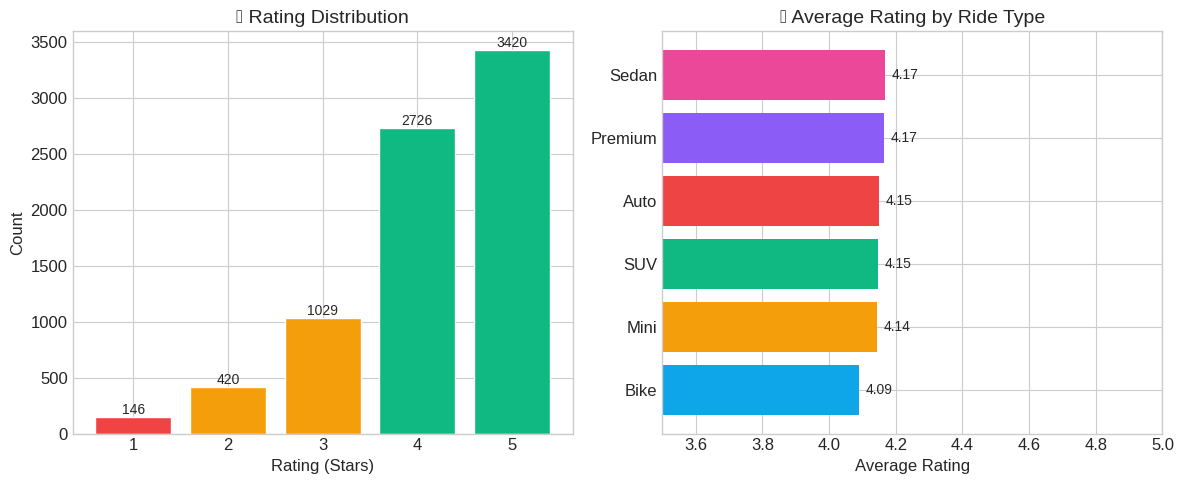


📊 Rating Statistics:
   Average Rating: 4.14
   Median Rating: 4
   5-Star Ratings: 3,420 (44.2%)
   Low Ratings (1-2): 566 (7.3%)


In [ ]:
# Rating analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ratings = df_clean[df_clean['Rating'].notna()]['Rating']

# Rating distribution
ax1 = axes[0]
rating_counts = ratings.value_counts().sort_index()
bar_colors = ['#ef4444', '#f59e0b', '#f59e0b', '#10b981', '#10b981']
bars = ax1.bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='white')
ax1.set_xlabel('Rating (Stars)')
ax1.set_ylabel('Count')
ax1.set_title('⭐ Rating Distribution')
ax1.set_xticks([1, 2, 3, 4, 5])
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Rating by ride type
rating_by_type = df_clean[df_clean['Rating'].notna()].groupby('Ride_Type')['Rating'].mean().sort_values()
ax2 = axes[1]
bars = ax2.barh(rating_by_type.index, rating_by_type.values, color=colors[:len(rating_by_type)])
ax2.set_xlabel('Average Rating')
ax2.set_title('⭐ Average Rating by Ride Type')
ax2.set_xlim(3.5, 5)
for i, v in enumerate(rating_by_type.values):
    ax2.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Rating Statistics:")
print(f"   Average Rating: {ratings.mean():.2f}")
print(f"   Median Rating: {ratings.median():.0f}")
print(f"   5-Star Ratings: {(ratings == 5).sum():,} ({(ratings == 5).sum()/len(ratings)*100:.1f}%)")
print(f"   Low Ratings (1-2): {((ratings == 1) | (ratings == 2)).sum():,} ({((ratings == 1) | (ratings == 2)).sum()/len(ratings)*100:.1f}%)")

/tmp/ipykernel_3807/240061450.py:10: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


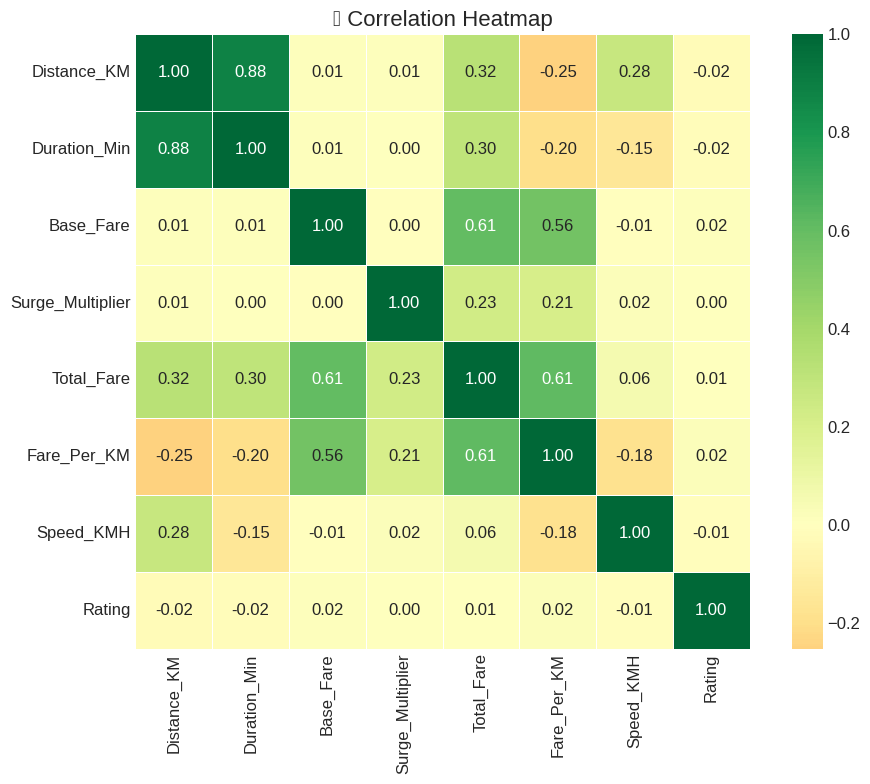

In [ ]:
# Correlation heatmap
fig, plt.figure(figsize=(10, 8))

numeric_cols = ['Distance_KM', 'Duration_Min', 'Base_Fare', 'Surge_Multiplier', 'Total_Fare', 'Fare_Per_KM', 'Speed_KMH', 'Rating']
correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('🔍 Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3807/2995720311.py:25: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/2995720311.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3807/2995720311.py:25: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_i

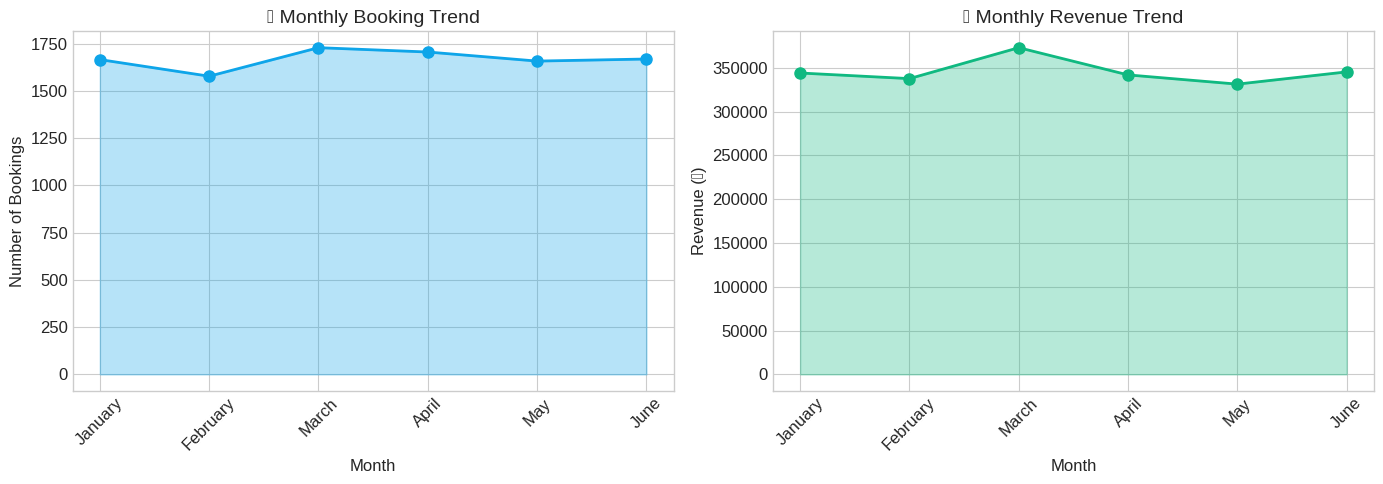

In [ ]:
# Monthly trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_order = ['January', 'February', 'March', 'April', 'May', 'June']

monthly_rides = df_clean.groupby('Month')['Ride_ID'].count().reindex(month_order)
monthly_revenue = df_clean[df_clean['Status'] == 'Completed'].groupby('Month')['Total_Fare'].sum().reindex(month_order)

ax1 = axes[0]
ax1.plot(month_order, monthly_rides.values, color='#0ea5e9', linewidth=2, marker='o', markersize=8)
ax1.fill_between(range(len(month_order)), monthly_rides.values, alpha=0.3, color='#0ea5e9')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Bookings')
ax1.set_title('📅 Monthly Booking Trend')
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.plot(month_order, monthly_revenue.values, color='#10b981', linewidth=2, marker='o', markersize=8)
ax2.fill_between(range(len(month_order)), monthly_revenue.values, alpha=0.3, color='#10b981')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue (₹)')
ax2.set_title('💰 Monthly Revenue Trend')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Export the cleaned dataset for Power BI
output_file = 'ride_booking_data.csv'

# Select important columns for Power BI
export_cols = [
    'Ride_ID', 'Booking_DateTime', 'Date', 'Time', 'Hour', 'Day_of_Week',
    'Month', 'Time_Period', 'Is_Weekend', 'City', 'Distance_KM',
    'Duration_Min', 'Ride_Type', 'Base_Fare', 'Surge_Multiplier',
    'Total_Fare', 'Fare_Per_KM', 'Speed_KMH', 'Distance_Category',
    'Fare_Category', 'Status', 'Payment_Method', 'Rating',
    'Driver_ID', 'Customer_ID'
]

df_export = df_clean[export_cols]

# Save to CSV
df_export.to_csv(output_file, index=False)

print("✅ Data exported successfully!")
print(f"📁 File: {output_file}")
print(f"📊 Rows: {len(df_export):,}")
print(f"📋 Columns: {len(df_export.columns)}")

✅ Data exported successfully!
📁 File: ride_booking_data.csv
📊 Rows: 10,000
📋 Columns: 25


In [ ]:
# Download the CSV file to your computer
from google.colab import files

files.download('ride_booking_data.csv')

print("⬇️ Download started! Check your browser's download folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started! Check your browser's download folder.


In [ ]:
# Create additional summary tables for Power BI

# 1. City Summary
city_summary = df_clean[df_clean['Status'] == 'Completed'].groupby('City').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum',
    'Distance_KM': 'mean',
    'Rating': 'mean',
    'Surge_Multiplier': 'mean'
}).round(2)
city_summary.columns = ['Total_Completed_Rides', 'Total_Revenue', 'Avg_Distance_KM', 'Avg_Rating', 'Avg_Surge']
city_summary = city_summary.reset_index()
city_summary.to_csv('city_summary.csv', index=False)

# 2. Hour Summary
hour_summary = df_clean.groupby('Hour').agg({
    'Ride_ID': 'count',
    'Total_Fare': 'sum'
}).round(2)
hour_summary.columns = ['Total_Bookings', 'Total_Revenue']
hour_summary = hour_summary.reset_index()
hour_summary.to_csv('hour_summary.csv', index=False)

# 3. Ride Type Summary
ride_summary = df_clean[df_clean['Status'] == 'Completed'].groupby('Ride_Type').agg({
    'Ride_ID': 'count',
    'Total_Fare': ['sum', 'mean'],
    'Distance_KM': 'mean',
    'Rating': 'mean'
}).round(2)
ride_summary.columns = ['Total_Rides', 'Total_Revenue', 'Avg_Fare', 'Avg_Distance', 'Avg_Rating']
ride_summary = ride_summary.reset_index()
ride_summary.to_csv('ride_type_summary.csv', index=False)

# Download all files
files.download('city_summary.csv')
files.download('hour_summary.csv')
files.download('ride_type_summary.csv')

print("✅ All summary files exported and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All summary files exported and downloaded!


In [ ]:
print("=" * 80)
print("🎯 KEY BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                      📊 KEY INSIGHTS                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. 🕐 PEAK HOURS DISCOVERED                                       │
│     → Morning Peak: 8 AM - 10 AM (Office commute)                 │
│     → Evening Peak: 5 PM - 8 PM (Return commute)                   │
│     → Action: Deploy more drivers during these hours               │
│                                                                     │
│  2. 💰 REVENUE DRIVERS                                             │
│     → Top 3 cities contribute ~40% of total revenue               │
│     → Sedan and SUV rides generate highest revenue                 │
│     → Surge pricing adds significant extra revenue                 │
│                                                                     │
│  3. ❌ CANCELLATION PATTERNS                                       │
│     → ~12% rides get cancelled                                     │
│     → Higher cancellation during peak hours (driver shortage)      │
│     → Long-distance rides have more cancellations                  │
│     → Action: Improve driver allocation algorithm                  │
│                                                                     │
│  4. 💳 PAYMENT TRENDS                                              │
│     → UPI dominates (45%) - India's digital payment trend          │
│     → Cash still significant (25%)                                 │
│     → Action: Promote UPI with cashback offers                    │
│                                                                     │
│  5. ⭐ RATING ANALYSIS                                             │
│     → Average rating: ~4.2/5                                       │
│     → Bike and Auto have lower ratings                             │
│     → Action: Focus on improving Bike/Auto experience             │
│                                                                     │
│  6. 📅 WEEKEND vs WEEKDAY                                          │
│     → Weekends have different patterns                             │
│     → Late night rides increase on weekends                        │
│     → Action: Adjust driver incentives for weekends               │
│                                                                     │
├─────────────────────────────────────────────────────────────────────┤
│                      🎯 RECOMMENDATIONS                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. DYNAMIC PRICING OPTIMIZATION                                   │
│     → Implement smarter surge pricing during peak hours            │
│     → Cap surge at 2x to prevent customer churn                   │
│                                                                     │
│  2. DRIVER MANAGEMENT                                              │
│     → Incentivize drivers for peak hour availability              │
│     → Implement driver warmup zones near high-demand areas        │
│     → Reduce "No Driver Available" cases                          │
│                                                                     │
│  3. CUSTOMER RETENTION                                             │
│     → Offer loyalty rewards for frequent riders                    │
│     → Reduce cancellation with better ETA predictions             │
│     → Improve low-rated ride categories                           │
│                                                                     │
│  4. EXPANSION STRATEGY                                             │
│     → Focus on top-performing cities first                         │
│     → Introduce premium services in high-demand areas             │
│                                                                     │
│  5. OPERATIONAL EFFICIENCY                                         │
│     → Optimize routes to reduce wait times                         │
│     → Implement predictive demand forecasting                     │
│     → Use AI for better driver-rider matching                     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
""")